In [2]:
import os
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from sklearn.feature_selection import VarianceThreshold

print("Step 1: Ingesting Clean Structural Cache File...")

CACHE_FILE = "/home/bedanga-b-bora/Documents/cyp19a1_cid_smiles_cache.csv"

if not os.path.exists(CACHE_FILE):
    raise FileNotFoundError(f"Could not locate {CACHE_FILE}. Make sure it is in your active working directory!")

df_clean = pd.read_csv(CACHE_FILE)
df_clean = df_clean.dropna(subset=["SMILES"]).reset_index(drop=True)
print(f"Successfully loaded {df_clean.shape[0]} verified molecules from local disk cache.")

print("\nStep 2: Engineering Molecular Features...")

def compute_physicochemical_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: 
        return [np.nan] * 4
    return [
        Descriptors.MolWt(mol),       # So I don't forget, this is the molecular weight of the compound
        Descriptors.MolLogP(mol),     # and this is the octanol-water partition coefficient (LogP) for lipophilicity
        Descriptors.NumHDonors(mol),   # oh this should be the number of hydrogen bond donors (HBD) in the molecule
        Descriptors.TPSA(mol)         # not sure but this is the topological polar surface area (TPSA) for polarity metrics
    ]

print(" -> Extracting physical property metrics (MolWt, LogP, HDonors, TPSA)...")
desc_data = [compute_physicochemical_descriptors(s) for s in df_clean['SMILES']]
df_desc = pd.DataFrame(desc_data, columns=['MolWt', 'LogP', 'HDonors', 'TPSA'], index=df_clean.index)

df_pipeline = pd.concat([df_clean, df_desc], axis=1).dropna(subset=['MolWt'])

def compute_structural_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(2048)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048))

print(" -> Computing high-dimensional structural bit arrays...")
X_fingerprints = np.array([compute_structural_fingerprint(s) for s in df_pipeline['SMILES']])
X_descriptors = df_pipeline[['MolWt', 'LogP', 'HDonors', 'TPSA']].values

X_raw_features = np.hstack([X_fingerprints, X_descriptors])

print("\nStep 3: Creating Binary Activity Targets...")

if 'target' not in df_pipeline.columns:
    potency_column = 'Activity_Value' if 'Activity_Value' in df_pipeline.columns else df_pipeline.select_dtypes(include=[np.number]).columns[0]
    mid_thresh = df_pipeline[potency_column].median()
    df_pipeline['target'] = (df_pipeline[potency_column] <= mid_thresh).astype(int)

y = df_pipeline['target'].values

print("\n=== Feature Processing Summary ===")
print(f"Total Structural Array Dimensions: {X_raw_features.shape}")
print(f"Target Distribution Profile: {np.bincount(y)[1]} Active Scaffolds vs {np.bincount(y)[0]} Inactive Scaffolds.")

Step 1: Ingesting Clean Structural Cache File...
Successfully loaded 11787 verified molecules from local disk cache.

Step 2: Engineering Molecular Features...
 -> Extracting physical property metrics (MolWt, LogP, HDonors, TPSA)...


[08:36:08] WARNING: not removing hydrogen atom without neighbors
[08:36:08] WARNING: not removing hydrogen atom without neighbors
[08:36:10] WARNING: not removing hydrogen atom without neighbors
[08:36:10] DEPRECATION WARNING: please use MorganGenerator


 -> Computing high-dimensional structural bit arrays...


[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerator
[08:36:10] DEPRECATION WARNING: please use MorganGenerat


Step 3: Creating Binary Activity Targets...

=== Feature Processing Summary ===
Total Structural Array Dimensions: (11787, 2052)
Target Distribution Profile: 5894 Active Scaffolds vs 5893 Inactive Scaffolds.


[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator
[08:36:22] DEPRECATION WARNING: please use MorganGenerator


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Step 4: Stratified Train-Test Partitioning...")

X_train, X_test, y_train, y_test = train_test_split(
    X_raw_features, y, test_size=0.2, random_state=42, stratify=y
)

print(f" -> Training matrix footprint: {X_train.shape}")
print(f" -> Testing matrix footprint:  {X_test.shape}")

print("\nStep 5: Feature Normalization & Filtering...")

X_train_fp, X_train_desc = X_train[:, :2048], X_train[:, 2048:]
X_test_fp, X_test_desc = X_test[:, :2048], X_test[:, 2048:]

selector = VarianceThreshold(threshold=0.01)
X_train_fp_filtered = selector.fit_transform(X_train_fp)
X_test_fp_filtered = selector.transform(X_test_fp)

print(f" -> Stripped low-variance fingerprint bits down from 2048 columns to {X_train_fp_filtered.shape[1]}")

scaler = StandardScaler()
X_train_desc_scaled = scaler.fit_transform(X_train_desc)
X_test_desc_scaled = scaler.transform(X_test_desc)

X_train_processed = np.hstack([X_train_fp_filtered, X_train_desc_scaled])
X_test_processed = np.hstack([X_test_fp_filtered, X_test_desc_scaled])

print("\n=== Data Preprocessing Pipeline Finalized ===")
print(f"Final training input dimension shape: {X_train_processed.shape}")
print(f"Final testing input dimension shape:  {X_test_processed.shape}")

Step 4: Stratified Train-Test Partitioning...
 -> Training matrix footprint: (9429, 2052)
 -> Testing matrix footprint:  (2358, 2052)

Step 5: Feature Normalization & Filtering...
 -> Stripped low-variance fingerprint bits down from 2048 columns to 639

=== Data Preprocessing Pipeline Finalized ===
Final training input dimension shape: (9429, 643)
Final testing input dimension shape:  (2358, 643)


In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

RANDOM_STATE = 42

print("Initializing model competitive screening grid...\n")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(probability=True, random_state=RANDOM_STATE),
    "XGBoost Classifier": XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
}

benchmark_metrics = []

for name, model in models.items():
    print(f" -> Training {name} on processed chemical features...")
    model.fit(X_train_processed, y_train)
    
    preds = model.predict(X_test_processed)
    probs = model.predict_proba(X_test_processed)[:, 1]
    
    benchmark_metrics.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

df_leaderboard = pd.DataFrame(benchmark_metrics)
print("\n========================= MODEL SCREENING LEADERBOARD =========================")
display(df_leaderboard.sort_values(by="F1-Score", ascending=False).reset_index(drop=True))

Initializing model competitive screening grid...

 -> Training Logistic Regression on processed chemical features...
 -> Training Random Forest on processed chemical features...
 -> Training Support Vector Machine on processed chemical features...


/home/bedanga-b-bora/miniconda3/envs/gmx_env/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


 -> Training XGBoost Classifier on processed chemical features...

========================= MODEL SCREENING LEADERBOARD =========================


,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Support Vector Machine,0.873622,0.853815,0.901612,0.877063,0.938917
1,Random Forest,0.871501,0.855519,0.893978,0.874326,0.939017
2,XGBoost Classifier,0.866412,0.858209,0.877863,0.867925,0.938360
3,Logistic Regression,0.842239,0.823058,0.871925,0.846787,0.909136


Extracting metrics for the top-performing architecture: Support Vector Machine...


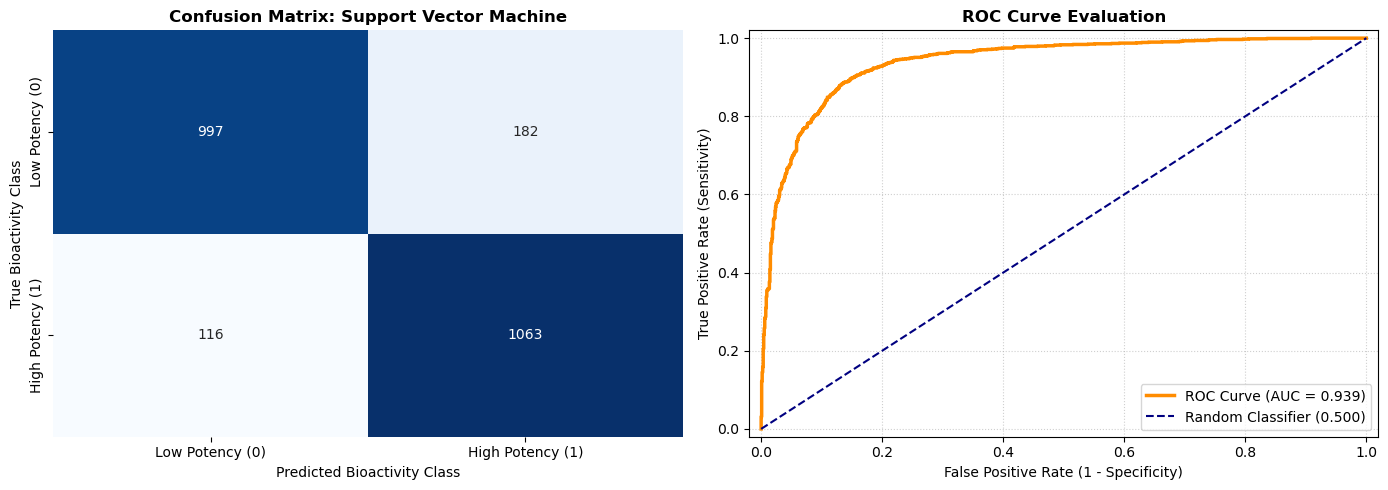


=================== CLASS-LEVEL EVALUATION REPORT (SUPPORT VECTOR MACHINE) ===================
                        precision    recall  f1-score   support

 Low Potency (Class 0)       0.90      0.85      0.87      1179
High Potency (Class 1)       0.85      0.90      0.88      1179

              accuracy                           0.87      2358
             macro avg       0.87      0.87      0.87      2358
          weighted avg       0.87      0.87      0.87      2358



In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, classification_report, roc_auc_score

# 1. FIRST: Extract the best-performing architecture name and model from the leaderboard
best_model_row = df_leaderboard.sort_values(by="F1-Score", ascending=False).iloc[0]
best_model_name = best_model_row["Algorithm"]
best_model = models[best_model_name]

print(f"Extracting metrics for the top-performing architecture: {best_model_name}...")

# 2. Generate predictions and probability scores using the test matrix
best_preds = best_model.predict(X_test_processed)
best_probs = best_model.predict_proba(X_test_processed)[:, 1]

# 3. Initialize the visualization grid
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0], cbar=False,
            xticklabels=['Low Potency (0)', 'High Potency (1)'], 
            yticklabels=['Low Potency (0)', 'High Potency (1)'])
ax[0].set_title(f"Confusion Matrix: {best_model_name}", fontsize=12, fontweight='bold')
ax[0].set_ylabel("True Bioactivity Class", fontsize=10)
ax[0].set_xlabel("Predicted Bioactivity Class", fontsize=10)

# Plot B: Receiver Operating Characteristic (ROC) Curve
fpr, tpr, _ = roc_curve(y_test, best_probs)
auc_score = roc_auc_score(y_test, best_probs)

ax[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier (0.500)')
ax[1].set_xlim([-0.02, 1.02])
ax[1].set_ylim([-0.02, 1.02])
ax[1].set_title(f"ROC Curve Evaluation", fontsize=12, fontweight='bold')
ax[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=10)
ax[1].set_ylabel("True Positive Rate (Sensitivity)", fontsize=10)
ax[1].legend(loc="lower right", frameon=True)
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Print the final textual academic performance report
print(f"\n=================== CLASS-LEVEL EVALUATION REPORT ({best_model_name.upper()}) ===================")
print(classification_report(y_test, best_preds, target_names=['Low Potency (Class 0)', 'High Potency (Class 1)']))

This feels sooo good.